# Method comparison — relative error at ~fixed bits/vector

Loads relerr-style CSVs from **turboquant** (TQMSE, TQProd), **rabitq** (RaBitQ), **vaq** (VAQ), **relerr_cpp** (PQ, OPQ), and **LSQ++** (aggregate `*_LSQpp_adc_vs_exact_eval.csv` under `results/lsqpp`, optional `train_size` filter via `default_method_sources`). For each dataset and method, selects the run whose **bits_per_vector** is closest to `TARGET_BITS_PER_VECTOR` (tie-break: lower `rel_error_mean`). For an all-in-one CLI, see `scripts/figure_generators/all_methods_relerr_figures.py`.

- Set `MAX_ABS_BPV_DIFF` to drop matches that are too far from the target (e.g. avoids pairing OPQ at 16 bits with a 1024-bit target). Use `None` to always take the closest row regardless of distance.
- Fonts / grid follow `relerr_quick_plot_style` (same spirit as `relerr_cpp_plots.ipynb`).
- Adjust `METHODS` / `DATASETS` / paths if your results live elsewhere.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Repo root (directory containing hdvc_paths.py); run notebook with cwd inside the repo.
REPO = None
for anc in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (anc / "hdvc_paths.py").is_file():
        REPO = anc
        break
if REPO is None:
    raise RuntimeError("Could not find repo root (hdvc_paths.py). Open the notebook from the HDVC checkout.")
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts" / "figure_generators"))

from hdvc_paths import get_results_root  # noqa: E402

from method_comparison_relerr import (
    MethodSource,
    default_method_sources,
    load_concat_sources,
    build_comparison_table,
    plot_grouped_bar_relerr,
)

# --- Match all methods to roughly this total code size (bits per vector) ---
TARGET_BITS_PER_VECTOR = 1024

# Reject matches farther than this many bits from the target (None = no limit)
MAX_ABS_BPV_DIFF = 256

METHODS = ["TQMSE", "TQProd", "RaBitQ", "VAQ", "PQ", "OPQ", "LSQ++"]

DATASETS = ["bigann", "deep", "gist", "msmarco", "openai", "sift"]

DATA_ROOT = get_results_root()
OUT_DIR = DATA_ROOT / "figures" / "method_comparison"

LSQ_TRAIN_FILTER = 1_000_000  # set None to keep all LSQ++ train sizes (not recommended for bar match)
SOURCES = default_method_sources(DATA_ROOT, lsq_train_size_filter=LSQ_TRAIN_FILTER)

In [2]:
raw = load_concat_sources(SOURCES)
print(f"Loaded {len(raw)} rows, methods: {sorted(raw['method'].unique())}")

present = set(raw["dataset"].unique())
datasets = [d for d in DATASETS if d in present]
missing_ds = [d for d in DATASETS if d not in present]
if missing_ds:
    print("No data for datasets (skipped):", missing_ds)

comp = build_comparison_table(
    raw,
    datasets,
    METHODS,
    TARGET_BITS_PER_VECTOR,
    max_abs_bpv_diff=MAX_ABS_BPV_DIFF,
)

comp

bpv_cols = [c for c in comp.columns if c.endswith("_bits_per_vector")]
if bpv_cols:
    deltas = comp[bpv_cols].apply(lambda s: (s - TARGET_BITS_PER_VECTOR).abs())
    print("Max |bits_per_vector - target| per method:")
    print(deltas.max(numeric_only=True))

Loaded 411 rows, methods: ['OPQ', 'PQ']
No data for datasets (skipped): ['sift']
Max |bits_per_vector - target| per method:
TQMSE_bits_per_vector      NaN
TQProd_bits_per_vector     NaN
RaBitQ_bits_per_vector     NaN
VAQ_bits_per_vector        NaN
PQ_bits_per_vector        64.0
OPQ_bits_per_vector       64.0
LSQ++_bits_per_vector      NaN
dtype: float64


/home/cpanourg/projects/2-hdvc/scripts/figure_generators/method_comparison_relerr.py:70: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  return pd.concat(frames, ignore_index=True)


Saved: /home/cpanourg/projects/2-hdvc/results/figures/method_comparison


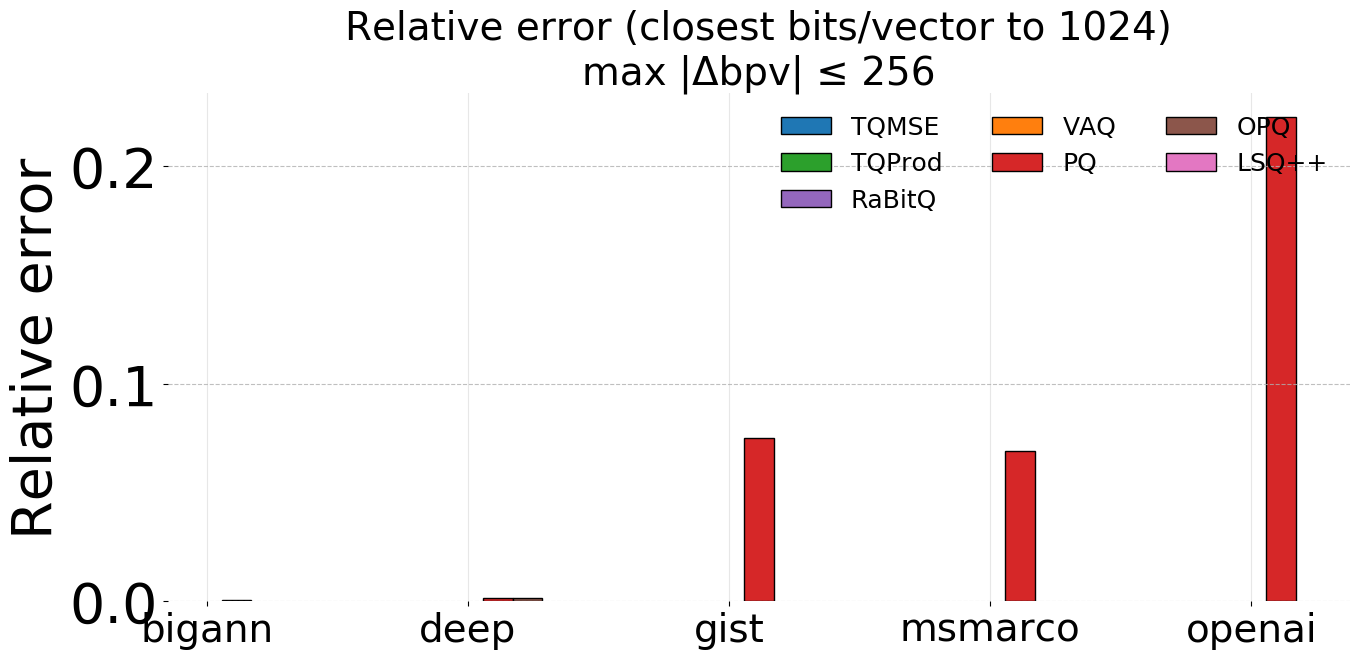

In [3]:
fig, ax = plot_grouped_bar_relerr(
    comp,
    METHODS,
    target_bits_per_vector=TARGET_BITS_PER_VECTOR,
    title_suffix=f"max |Δbpv| ≤ {MAX_ABS_BPV_DIFF}" if MAX_ABS_BPV_DIFF is not None else "closest row (no Δ limit)",
    figsize=(14, 7),
    output_path=OUT_DIR / f"relerr_compare_bpv~{TARGET_BITS_PER_VECTOR}.pdf",
    close_fig=False,
)

png = OUT_DIR / f"relerr_compare_bpv~{TARGET_BITS_PER_VECTOR}.png"
fig.savefig(png, dpi=200)
print("Saved:", OUT_DIR)

import matplotlib.pyplot as plt
plt.show()